# Pipeline 1: Donor Retention / Lapse Risk

**Organization:** River of Life / Lighthouse Sanctuary (INTEX)  
**Methodology:** CRISP-DM–aligned end-to-end ML (see `pipeline_guide.md`)

This notebook predicts **monetary donor lapse**—whether a supporter who has given money historically will **not** make another **monetary** gift within the next **105 days** (midpoint of the 90–120 day stewardship window requested by stakeholders).

---

## 1. Problem Framing

### Business problem
Lighthouse Sanctuary relies on recurring generosity to fund safehouses, education, and wellbeing programs. When donors lapse silently, revenue becomes volatile and staff lack a prioritized list for **thank-you, check-in, and reactivation** outreach.

### Stakeholders
| Stakeholder | Interest |
|-------------|----------|
| **Development / admin** | Who to contact this week; campaign load; retention KPIs |
| **Front-line staff** | Simple risk flags in the admin dashboard (not raw model math) |
| **Donors** | Timely, respectful engagement—not spam |

### Why this matters
Proactive retention typically costs far less than re-acquiring lapsed donors. A ranked lapse-risk list turns a vague “we should steward donors” goal into **operational workflows**.

### Predictive vs explanatory (both required)
- **Predictive:** Produce a **lapse probability** and **risk tier** per supporter to prioritize outreach (**decision:** whom to call or email first).
- **Explanatory:** Quantify **which behaviors** (recency, frequency, monetary patterns, program spread) associate with lapse—**decision:** how to design campaigns and messaging (for example, emphasize recurring giving if it is protective in the data).

### Decision the model supports
**Prioritization:** Given limited staff time, contact **high predicted lapse risk** donors who are still **high value** (frequency and tenure) first.

*Limitation:* Associations are **not causal**; interventions were not randomized. See Section 6.

---


## 2. Data Acquisition & Preparation

### Tables loaded
| Table | Role |
|-------|------|
| `supporters.csv` | Donor attributes (type, region, acquisition channel) |
| `donations.csv` | Gift history, amounts, recurrence, dates |
| `donation_allocations.csv` | How gifts map to programs and safehouses—**diversity** features |

### Join logic
1. **Donations → Supporters:** `donations.supporter_id` = `supporters.supporter_id` (many-to-one). Brings static demographics and supporter type onto each gift row when needed.
2. **Donations → Allocations:** `donations.donation_id` = `donation_allocations.donation_id` (one-to-many). Used to count distinct **program areas** funded before each snapshot date.

### Reproducibility
All paths are derived from a **project root** (`PROJECT_ROOT`). Random seeds are fixed. The **panel construction** (snapshot dates) is parameterized so batch scoring jobs can reuse the same functions.

### Target definition (operational)
- **Cohort:** Supporters with **at least one monetary donation** strictly before snapshot date `as_of_date`.
- **Lapse (positive class):** **No** monetary donation with `as_of_date` < `donation_date` ≤ `as_of_date + 105 days`.

We use **105 days** as a single horizon between 90 and 120 days to keep one clear label; you can set `LAPSE_HORIZON_DAYS = 90` or `120` for sensitivity analysis.

### Leakage control
Features use only donations with `donation_date < as_of_date`. Labels use only the **future** window **after** `as_of_date`.

### Multiple rows per donor
Monthly snapshots create a **panel**. Rows for the same `supporter_id` are correlated. **Evaluation uses `GroupKFold` and group hold-out by `supporter_id`** so metrics are not optimistically biased.

---


In [27]:
# Configuration & imports
from __future__ import annotations

import json
import warnings
from datetime import timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk", font_scale=0.85)

RANDOM_STATE = 42
LAPSE_HORIZON_DAYS = 105  # midpoint of 90–120 day window


def find_project_root() -> Path:
    """Resolve repo root whether cwd is project root or ml_pipelines/."""
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "lighthouse_csv_v7").is_dir():
            return p
    raise FileNotFoundError(
        "Could not find lighthouse_csv_v7. Run the notebook from the INTEX II EDA folder "
        "or set PROJECT_ROOT manually to that folder."
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "lighthouse_csv_v7"
OUTPUT_DIR = PROJECT_ROOT / "ml_pipelines" / "artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT.resolve())
print("LAPSE_HORIZON_DAYS:", LAPSE_HORIZON_DAYS)


PROJECT_ROOT: /Users/jaxon/Documents/BYU Archive/Winter 2026 - Junior Core IS/INTEX II/INTEX II EDA
LAPSE_HORIZON_DAYS: 105


In [28]:
def load_raw_tables(data_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    # Parse dates once at load for reproducible merges and filters.
    supporters = pd.read_csv(
        data_dir / "supporters.csv",
        parse_dates=["created_at", "first_donation_date"],
    )
    donations = pd.read_csv(
        data_dir / "donations.csv",
        parse_dates=["donation_date"],
    )
    allocations = pd.read_csv(
        data_dir / "donation_allocations.csv",
        parse_dates=["allocation_date"],
    )
    return supporters, donations, allocations


supporters_df, donations_df, allocations_df = load_raw_tables(DATA_DIR)
donations_with_alloc = donations_df.merge(
    allocations_df, on="donation_id", how="left", validate="one_to_many"
)
monetary = donations_df[donations_df["donation_type"] == "Monetary"].copy()

print("supporters:", supporters_df.shape)
print("donations:", donations_df.shape)
print("allocations:", allocations_df.shape)
print("monetary gifts:", monetary.shape)


supporters: (60, 15)
donations: (420, 13)
allocations: (521, 7)
monetary gifts: (234, 13)


In [29]:
def winsorize_series(s: pd.Series, lower_q: float = 0.01, upper_q: float = 0.99) -> pd.Series:
    # Cap extreme values at quantiles to limit outlier leverage; document caps in EDA.
    lo, hi = s.quantile(lower_q), s.quantile(upper_q)
    return s.clip(lower=lo, upper=hi)


def build_donor_panel(
    monetary_df: pd.DataFrame,
    donations_alloc_df: pd.DataFrame,
    supporters: pd.DataFrame,
    anchor_start: str = "2023-07-01",
    anchor_end: str = "2025-09-01",
    lapse_horizon_days: int = LAPSE_HORIZON_DAYS,
) -> pd.DataFrame:
    # One row per (supporter_id, as_of_date) with RFM-style features and lapse label.
    anchors = pd.date_range(anchor_start, anchor_end, freq="MS")
    rows: list[dict] = []
    max_d = monetary_df["donation_date"].max()

    for as_of in anchors:
        window_end = as_of + timedelta(days=lapse_horizon_days)
        if window_end > max_d:
            continue

        past = monetary_df[monetary_df["donation_date"] < as_of]
        supporter_ids = past["supporter_id"].unique()

        for sid in supporter_ids:
            pm = past[past["supporter_id"] == sid].sort_values("donation_date")
            last_dt = pm["donation_date"].max()
            recency_days = int((as_of - last_dt).days)
            frequency = int(len(pm))
            amounts = pm["amount"].fillna(0.0)
            monetary_sum = float(amounts.sum())
            monetary_mean = float(amounts.mean())
            has_recurring = bool(pm["is_recurring"].fillna(False).astype(bool).any())
            first_dt = pm["donation_date"].min()
            tenure_days = int((as_of - first_dt).days)
            if frequency >= 2:
                gaps = pm["donation_date"].diff().dt.days.dropna()
                mean_intergift_days = float(gaps.mean())
            else:
                mean_intergift_days = np.nan

            da = donations_alloc_df[
                (donations_alloc_df["supporter_id"] == sid)
                & (donations_alloc_df["donation_date"] < as_of)
            ]
            n_distinct_program_areas = int(da["program_area"].nunique(dropna=True))
            n_allocation_records = int(da["allocation_id"].notna().sum())

            future = monetary_df[
                (monetary_df["supporter_id"] == sid)
                & (monetary_df["donation_date"] > as_of)
                & (monetary_df["donation_date"] <= window_end)
            ]
            lapse_next_window = int(len(future) == 0)

            rows.append(
                {
                    "supporter_id": sid,
                    "as_of_date": as_of,
                    "lapse_next_window": lapse_next_window,
                    "recency_days": recency_days,
                    "frequency": frequency,
                    "monetary_sum": monetary_sum,
                    "monetary_mean": monetary_mean,
                    "has_recurring": int(has_recurring),
                    "tenure_days": tenure_days,
                    "mean_intergift_days": mean_intergift_days,
                    "n_distinct_program_areas": n_distinct_program_areas,
                    "n_allocation_records": n_allocation_records,
                }
            )

    panel = pd.DataFrame(rows)
    med_gap = panel["mean_intergift_days"].median()
    panel["mean_intergift_days"] = panel["mean_intergift_days"].fillna(med_gap)

    for col in ["monetary_sum", "monetary_mean"]:
        panel[col] = winsorize_series(panel[col])

    panel = panel.merge(
        supporters[
            [
                "supporter_id",
                "supporter_type",
                "relationship_type",
                "region",
                "acquisition_channel",
            ]
        ],
        on="supporter_id",
        how="left",
    )
    return panel


panel_df = build_donor_panel(monetary, donations_with_alloc, supporters_df)
print(panel_df.shape)
print(panel_df["lapse_next_window"].value_counts(normalize=True).rename("proportion"))
panel_df.head()


(1168, 16)
lapse_next_window
1    0.6875
0    0.3125
Name: proportion, dtype: float64


,supporter_id,as_of_date,lapse_next_window,recency_days,frequency,monetary_sum,monetary_mean,has_recurring,tenure_days,mean_intergift_days,n_distinct_program_areas,n_allocation_records,supporter_type,relationship_type,region,acquisition_channel
0,36,2023-07-01,1,76,3,3195.36,1065.1200,0,167,45.500000,4,5,SocialMediaAdvocate,PartnerOrganization,Mindanao,WordOfMouth
1,37,2023-07-01,1,29,1,502.90,502.9000,0,29,125.400000,1,2,InKindDonor,PartnerOrganization,Visayas,Website
2,51,2023-07-01,0,51,1,1036.30,1036.3000,0,51,125.400000,1,1,InKindDonor,Local,Luzon,WordOfMouth
3,20,2023-07-01,1,93,4,3702.31,925.5775,1,148,18.333333,3,7,Volunteer,International,Luzon,PartnerReferral
4,38,2023-07-01,1,41,1,1757.44,1757.4400,1,41,125.400000,3,4,PartnerOrganization,PartnerOrganization,Mindanao,WordOfMouth


### Missing values
- **Monetary amount:** The modeling cohort uses **monetary** gifts; `amount` should be present. Any null is filled with 0 before aggregation so a rare bad row does not break the pipeline.
- **Mean inter-gift gap:** Undefined when only one gift exists before the snapshot; we impute the **median** gap across the panel (transparent; alternatives include dropping the feature for first-time-only rows).

### Outliers
**Monetary sum and mean** are winsorized at the 1st and 99th percentiles **within the panel** to limit leverage from very large one-off gifts.

---


## 3. Exploration (EDA)

We examine distributions and relationships that map to **stewardship theory**: recency, frequency, monetary value (RFM), recurring behavior, and **program-area breadth** from allocations.

**Insight goal:** If longer recency aligns with lapse, shorten **feedback loops** (timely impact stories). If recurring flags are protective, invest in **sustainer conversion**. If program breadth matters, messaging can reference **multiple impact lines** donors already fund.

---


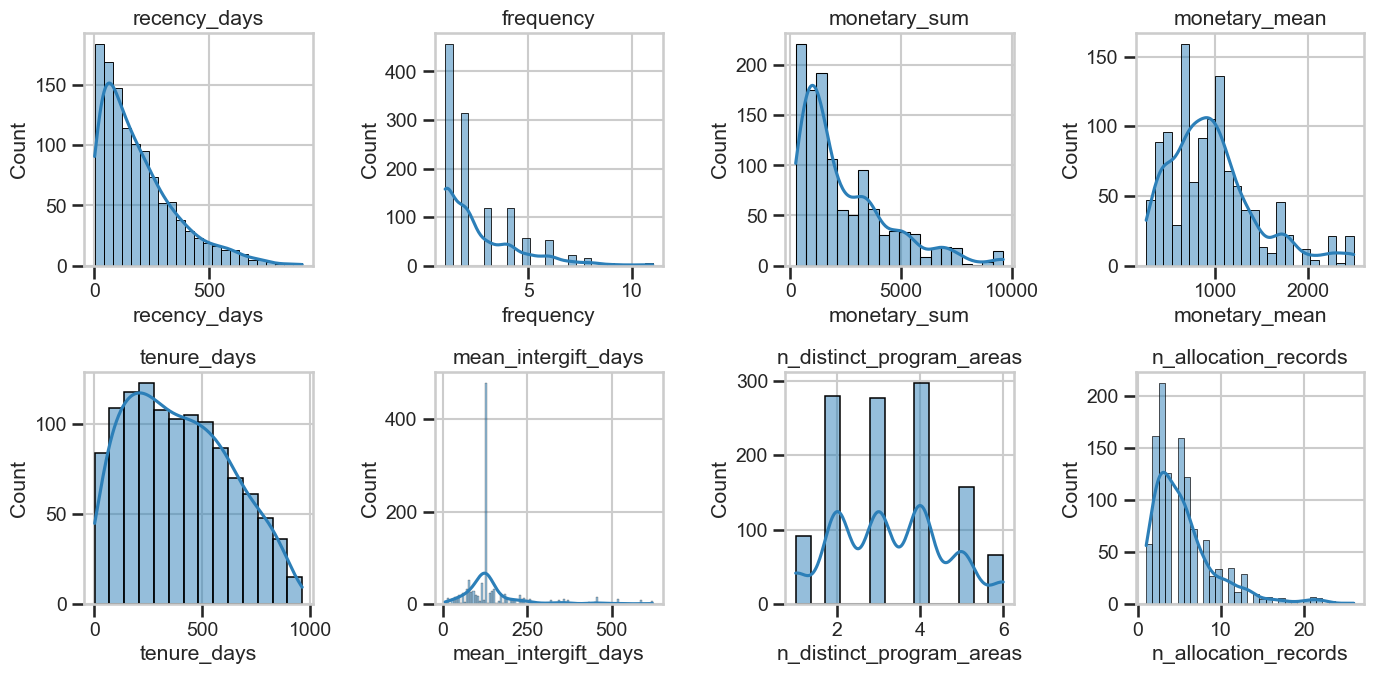

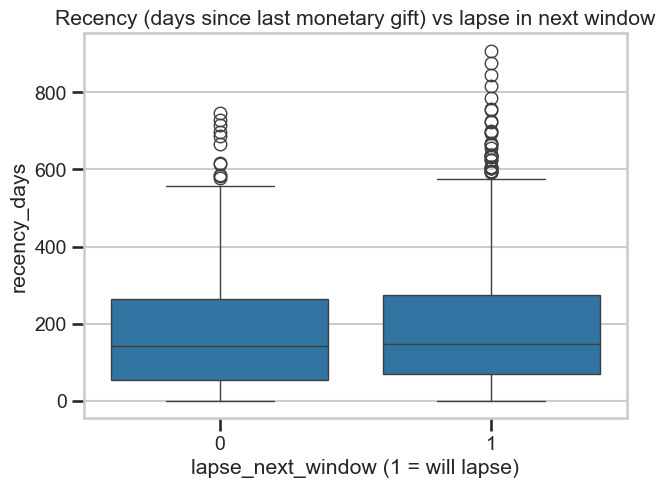

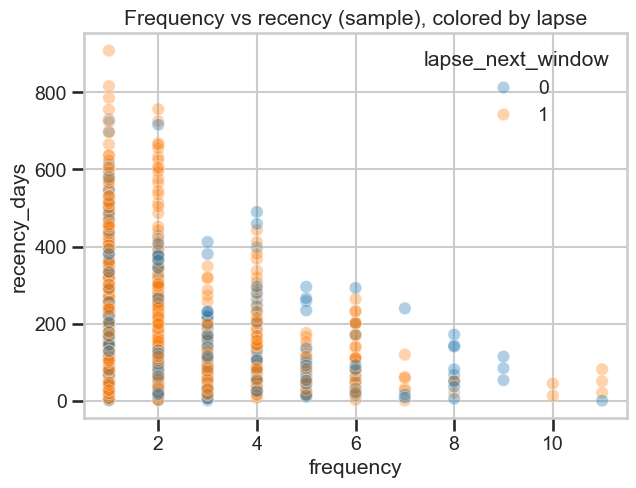

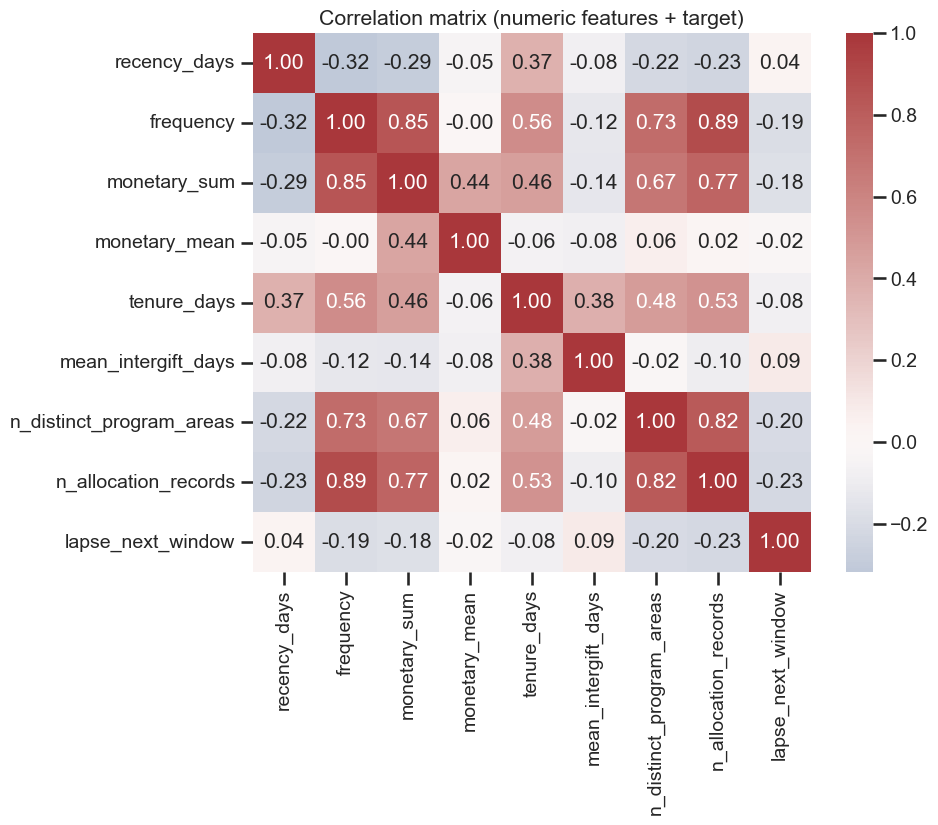

In [30]:
eda = panel_df.copy()
numeric_cols = [
    "recency_days",
    "frequency",
    "monetary_sum",
    "monetary_mean",
    "tenure_days",
    "mean_intergift_days",
    "n_distinct_program_areas",
    "n_allocation_records",
]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()
for ax, col in zip(axes, numeric_cols):
    sns.histplot(eda[col], kde=True, ax=ax, color="#2c7fb8")
    ax.set_title(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=eda, x="lapse_next_window", y="recency_days")
plt.title("Recency (days since last monetary gift) vs lapse in next window")
plt.xlabel("lapse_next_window (1 = will lapse)")
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=eda.sample(min(800, len(eda)), random_state=RANDOM_STATE),
    x="frequency",
    y="recency_days",
    hue="lapse_next_window",
    alpha=0.35,
)
plt.title("Frequency vs recency (sample), colored by lapse")
plt.show()

corr = eda[numeric_cols + ["lapse_next_window"]].corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation matrix (numeric features + target)")
plt.show()


In [31]:
cat_summary = (
    eda.groupby("supporter_type")["lapse_next_window"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "lapse_rate"})
    .sort_values("lapse_rate", ascending=False)
)
cat_summary


,lapse_rate,count
supporter_type,,
Volunteer,0.788462,156
SocialMediaAdvocate,0.783898,236
InKindDonor,0.733533,334
PartnerOrganization,0.623529,85
SkillsContributor,0.603448,58
MonetaryDonor,0.541806,299


### EDA takeaways (business language)
- **Recency** often separates lapse vs active-in-window rows: donors who have gone longer without a monetary gift are more likely to have **no** gift in the next ~15 weeks—consistent with RFM.
- **Frequency and tenure** help distinguish one-time testers from habitual givers; correlation strength is **descriptive**, not causal.
- **Allocations breadth** proxies depth of engagement with specific programs; if it shows up in models, stewardship can reference **concrete funded areas**.

---


## 4. Modeling & Feature Selection

### Feature set (justification)
| Feature | Rationale |
|---------|-----------|
| `recency_days` | Core RFM: time since last monetary gift |
| `frequency` | Loyalty and habit |
| `monetary_sum`, `monetary_mean` | Historical monetary value |
| `has_recurring` | Sustainer behavior; often stabilizes cash flow |
| `tenure_days` | Relationship age with monetary giving |
| `mean_intergift_days` | Cadence; irregular donors may need different nudges |
| `n_distinct_program_areas`, `n_allocation_records` | Mission engagement breadth and granularity |
| `supporter_type`, `relationship_type`, `region`, `acquisition_channel` | Segments and acquisition context |

### Explanatory model
**Logistic regression (L2)** on scaled numeric features and one-hot categoricals: **interpretable coefficients** (direction on the log-odds scale).

### Predictive models
**Random forest** and **gradient boosted trees** capture nonlinearities; on small data they may **overfit**, so we compare honestly with **grouped cross-validation**.

### Feature selection
**L1 logistic regression** inside `SelectFromModel` provides a transparent gate; we report test metrics after selection vs the full logistic baseline.

---


In [32]:
FEATURE_NUM = [
    "recency_days",
    "frequency",
    "monetary_sum",
    "monetary_mean",
    "has_recurring",
    "tenure_days",
    "mean_intergift_days",
    "n_distinct_program_areas",
    "n_allocation_records",
]
FEATURE_CAT = [
    "supporter_type",
    "relationship_type",
    "region",
    "acquisition_channel",
]

X = panel_df[FEATURE_NUM + FEATURE_CAT]
y = panel_df["lapse_next_window"]
groups = panel_df["supporter_id"]

preprocess = ColumnTransformer(
    [
        ("num", StandardScaler(), FEATURE_NUM),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            FEATURE_CAT,
        ),
    ]
)


def make_full_pipeline(classifier) -> Pipeline:
    return Pipeline(
        steps=[
            ("prep", preprocess),
            ("clf", classifier),
        ]
    )


gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
group_train = groups.iloc[train_idx]

print("Train rows", len(X_train), "unique supporters", group_train.nunique())
print("Test rows", len(X_test), "unique supporters", groups.iloc[test_idx].nunique())


Train rows 850 unique supporters 41
Test rows 318 unique supporters 14


In [33]:
models = {
    "logistic_l2_balanced": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "gradient_boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE,
        max_depth=3,
        learning_rate=0.05,
        n_estimators=200,
    ),
}

scoring = ["roc_auc", "f1", "precision", "recall", "accuracy"]
gkf = GroupKFold(n_splits=5)

cv_rows = []
for name, est in models.items():
    pipe = make_full_pipeline(est)
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=gkf,
        groups=group_train,
        scoring=scoring,
        n_jobs=-1,
    )
    row = {"model": name}
    for m in scoring:
        key = f"test_{m}"
        row[f"{m}_mean"] = scores[key].mean()
        row[f"{m}_std"] = scores[key].std()
    cv_rows.append(row)

cv_summary = pd.DataFrame(cv_rows).set_index("model").sort_values("roc_auc_mean", ascending=False)
cv_summary


,roc_auc_mean,roc_auc_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,accuracy_mean,accuracy_std
model,,,,,,,,,,
logistic_l2_balanced,0.650459,0.087407,0.635026,0.129730,0.810067,0.088845,0.531729,0.142088,0.589332,0.093969
random_forest,0.582389,0.061172,0.736689,0.084405,0.778810,0.046255,0.709941,0.144649,0.656344,0.072601
gradient_boosting,0.556695,0.092666,0.691076,0.121025,0.720014,0.063018,0.683335,0.188206,0.596370,0.106716


In [34]:
best_name = cv_summary.index[0]
best_est = models[best_name]
best_pipe = make_full_pipeline(best_est)
best_pipe.fit(X_train, y_train)

y_proba = best_pipe.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba),
}
print("Selected model:", best_name)
pd.Series(metrics, name="test_set")


Selected model: logistic_l2_balanced


accuracy     0.610063
precision    0.711864
recall       0.633166
f1           0.670213
roc_auc      0.610743
Name: test_set, dtype: float64

                  precision    recall  f1-score   support

active_in_window       0.48      0.57      0.52       119
           lapse       0.71      0.63      0.67       199

        accuracy                           0.61       318
       macro avg       0.60      0.60      0.60       318
    weighted avg       0.63      0.61      0.62       318



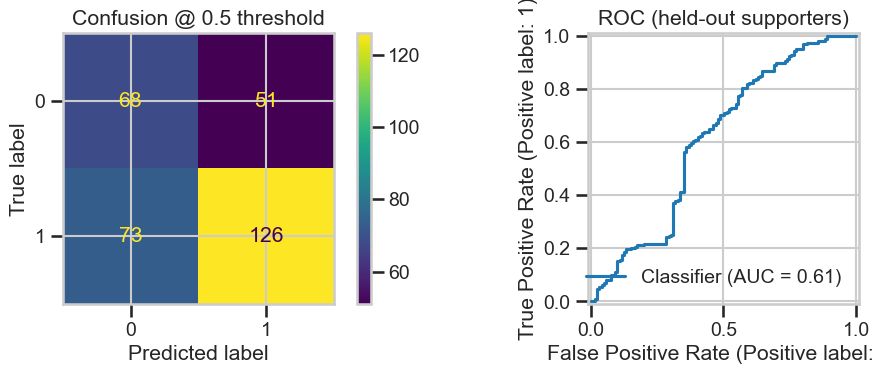

In [35]:
print(classification_report(y_test, y_pred, target_names=["active_in_window", "lapse"], zero_division=0))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0])
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax[1])
ax[0].set_title("Confusion @ 0.5 threshold")
ax[1].set_title("ROC (held-out supporters)")
plt.tight_layout()
plt.show()


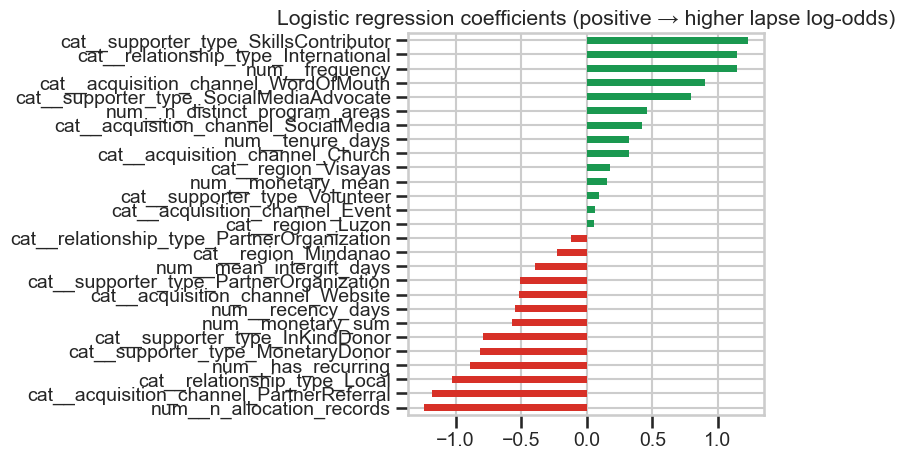

(num__tenure_days                           0.321900
 cat__acquisition_channel_SocialMedia       0.418626
 num__n_distinct_program_areas              0.458311
 cat__supporter_type_SocialMediaAdvocate    0.794845
 cat__acquisition_channel_WordOfMouth       0.903291
 num__frequency                             1.146380
 cat__relationship_type_International       1.148559
 cat__supporter_type_SkillsContributor      1.228257
 dtype: float64,
 num__n_allocation_records                  -1.237423
 cat__acquisition_channel_PartnerReferral   -1.181603
 cat__relationship_type_Local               -1.027334
 num__has_recurring                         -0.893368
 cat__supporter_type_MonetaryDonor          -0.815211
 cat__supporter_type_InKindDonor            -0.788476
 num__monetary_sum                          -0.571959
 num__recency_days                          -0.549938
 dtype: float64)

In [36]:
log_pipe = make_full_pipeline(
    LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
)
log_pipe.fit(X_train, y_train)

prep = log_pipe.named_steps["prep"]
clf = log_pipe.named_steps["clf"]
feature_names = prep.get_feature_names_out()
coefs = pd.Series(clf.coef_.ravel(), index=feature_names).sort_values()

plt.figure(figsize=(8, max(4, len(coefs) * 0.18)))
coefs.plot(kind="barh", color=np.where(coefs.values < 0, "#d73027", "#1a9850"))
plt.title("Logistic regression coefficients (positive → higher lapse log-odds)")
plt.tight_layout()
plt.show()

coefs.tail(8), coefs.head(8)


In [37]:
selector_pipe = Pipeline(
    [
        ("prep", preprocess),
        (
            "select",
            SelectFromModel(
                LogisticRegression(
                    penalty="l1",
                    solver="saga",
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    C=0.3,
                ),
                threshold="median",
            ),
        ),
        (
            "clf",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

selector_pipe.fit(X_train, y_train)
sel_proba = selector_pipe.predict_proba(X_test)[:, 1]
sel_pred = (sel_proba >= 0.5).astype(int)
print("L1-selected logistic — test ROC-AUC:", roc_auc_score(y_test, sel_proba))
print(classification_report(y_test, sel_pred, zero_division=0))


L1-selected logistic — test ROC-AUC: 0.6431316245091001
              precision    recall  f1-score   support

           0       0.57      0.46      0.51       119
           1       0.71      0.79      0.75       199

    accuracy                           0.67       318
   macro avg       0.64      0.63      0.63       318
weighted avg       0.66      0.67      0.66       318



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 5. Evaluation & Interpretation (business terms)

### Metrics used
- **ROC-AUC:** How well scores rank lapses vs non-lapses across thresholds—useful when you will **tune the cutoff** based on staff capacity.
- **Recall:** Share of true lapses flagged—**prioritize higher recall** if missing a lapsing donor is costlier than an extra stewardship touch.
- **Precision:** Share of flagged donors who truly lapse—important when outreach volume is capped.
- **F1:** Harmonic compromise when you need a single headline number.

### Trade-offs
- **False negative:** Donor lapses but the model says low risk → **lost relationship and revenue**. Mitigation: lower the probability threshold or use **tiered** outreach (calls for top decile, email for the next).
- **False positive:** Donor would have given anyway but receives heavy touch → **possible donor fatigue**. Mitigation: gratitude-first scripts; avoid urgent guilt framing.

### Reading performance
Absolute metrics vary by supporter split; **grouped CV** is the main guardrail. In production, track **calibration** and **drift** quarterly.

---


## 6. Causal & Relationship Analysis

### What we learned (associational)
Logistic coefficients and tree-based rankings describe **which historical patterns co-occur** with lapse in the next ~15 weeks—often **longer recency**, sometimes **lower frequency**, plus segment differences.

### Causality disclaimer
We did **not** randomize stewardship treatments. A negative coefficient on `has_recurring` means **sustainers tended to lapse less** in this window—not that **forcing** recurring enrollment causes retention without confounding (capacity to give, commitment, and so on).

### Most important features
Use the **coefficient bar chart**: positive values increase **log-odds of lapse**; negative values suggest **lower lapse risk** holding other features fixed (linear approximation).

**Limitations:** Few unique supporters; panel rows are correlated; holidays, disasters, and campaigns are not explicitly modeled.

---


## 7. Deployment Plan

### How predictions are used in the app
1. A **batch scoring job** (scheduled nightly or weekly) in Python reads current `donations` and `supporters` (from a warehouse export or read replica).
2. The job builds features **as of `run_date`** and writes **one row per scored monetary donor** into PostgreSQL.
3. The **.NET admin app** queries `donor_lapse_predictions` to populate a **stewardship queue** (sortable by risk and approximate value).

### Output schema (PostgreSQL)

```sql
CREATE TABLE IF NOT EXISTS donor_lapse_predictions (
    prediction_id BIGSERIAL PRIMARY KEY,
    supporter_id INTEGER NOT NULL REFERENCES supporters(supporter_id),
    as_of_date DATE NOT NULL,
    lapse_horizon_days INTEGER NOT NULL,
    lapse_probability DOUBLE PRECISION NOT NULL,
    risk_category VARCHAR(16) NOT NULL,
    model_version VARCHAR(32) NOT NULL,
    top_positive_drivers JSONB,
    scored_at TIMESTAMPTZ NOT NULL DEFAULT NOW(),
    UNIQUE (supporter_id, as_of_date, lapse_horizon_days, model_version)
);

CREATE INDEX idx_donor_lapse_risk ON donor_lapse_predictions (risk_category, scored_at DESC);
CREATE INDEX idx_donor_lapse_supporter ON donor_lapse_predictions (supporter_id);
```

**Example tier policy:** **High** if probability ≥ 0.66, **Medium** if ≥ 0.33, else **Low**. Adjust tiers to match **weekly outreach capacity**.

### Data flow
`Python batch job → UPSERT PostgreSQL → .NET (EF Core or Dapper) → dashboard and optional CRM export`

### Sample upsert

```sql
INSERT INTO donor_lapse_predictions (
  supporter_id, as_of_date, lapse_horizon_days,
  lapse_probability, risk_category, model_version, top_positive_drivers
) VALUES (
  42, DATE '2026-04-06', 105, 0.71, 'High', 'donor_lapse_v1',
  '[{"feature":"recency_days","note":"Last monetary gift 140 days ago"}]'::jsonb
)
ON CONFLICT (supporter_id, as_of_date, lapse_horizon_days, model_version)
DO UPDATE SET
  lapse_probability = EXCLUDED.lapse_probability,
  risk_category = EXCLUDED.risk_category,
  top_positive_drivers = EXCLUDED.top_positive_drivers,
  scored_at = NOW();
```

### Artifacts
Production training should persist the fitted `Pipeline` with `joblib` under `ml_pipelines/artifacts/` with a version string matching `model_version`.

---


In [38]:
from joblib import dump


def risk_tier(p: float) -> str:
    if p >= 0.66:
        return "High"
    if p >= 0.33:
        return "Medium"
    return "Low"


final_pipe = make_full_pipeline(
    LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
)
final_pipe.fit(X, y)

latest_as_of = panel_df["as_of_date"].max()
score_rows = panel_df[panel_df["as_of_date"] == latest_as_of].copy()
X_score = score_rows[FEATURE_NUM + FEATURE_CAT]
score_rows = score_rows.assign(
    lapse_probability=final_pipe.predict_proba(X_score)[:, 1],
)
score_rows["risk_category"] = score_rows["lapse_probability"].map(risk_tier)
score_rows["model_version"] = "donor_lapse_v1"
score_rows["lapse_horizon_days"] = LAPSE_HORIZON_DAYS

preview = score_rows[
    [
        "supporter_id",
        "as_of_date",
        "lapse_horizon_days",
        "lapse_probability",
        "risk_category",
        "model_version",
        "recency_days",
        "frequency",
    ]
].sort_values("lapse_probability", ascending=False)

dump(final_pipe, OUTPUT_DIR / "donor_lapse_model.joblib")
preview.head(15)


,supporter_id,as_of_date,lapse_horizon_days,lapse_probability,risk_category,model_version,recency_days,frequency
1116,36,2025-09-01,105,0.852745,High,donor_lapse_v1,443,4
1146,18,2025-09-01,105,0.819623,High,donor_lapse_v1,327,2
1133,39,2025-09-01,105,0.792135,High,donor_lapse_v1,78,3
1166,58,2025-09-01,105,0.743542,High,donor_lapse_v1,593,1
1128,43,2025-09-01,105,0.726550,High,donor_lapse_v1,232,3
1157,10,2025-09-01,105,0.714239,High,donor_lapse_v1,206,2
1129,15,2025-09-01,105,0.678157,High,donor_lapse_v1,351,2
1159,40,2025-09-01,105,0.676928,High,donor_lapse_v1,207,1
1153,12,2025-09-01,105,0.668534,High,donor_lapse_v1,8,4
1162,53,2025-09-01,105,0.664483,High,donor_lapse_v1,624,1


In [39]:
records = preview.head(5).to_dict(orient="records")
for r in records:
    r["as_of_date"] = str(r["as_of_date"].date())

with open(OUTPUT_DIR / "donor_lapse_sample_predictions.jsonl", "w") as f:
    for r in records:
        f.write(json.dumps(r, default=str) + chr(10))

print("Wrote:", OUTPUT_DIR / "donor_lapse_model.joblib")
print("Wrote:", OUTPUT_DIR / "donor_lapse_sample_predictions.jsonl")


Wrote: /Users/jaxon/Documents/BYU Archive/Winter 2026 - Junior Core IS/INTEX II/INTEX II EDA/ml_pipelines/artifacts/donor_lapse_model.joblib
Wrote: /Users/jaxon/Documents/BYU Archive/Winter 2026 - Junior Core IS/INTEX II/INTEX II EDA/ml_pipelines/artifacts/donor_lapse_sample_predictions.jsonl


### What should the organization do differently?
- **Operations:** Maintain a **weekly stewardship queue** ordered by `lapse_probability` and approximate donor value (frequency times typical gift).
- **Fundraising:** Run **ethical A/B tests** on messaging suggested by coefficients (for example recurring conversion)—measure outcomes; do not treat regression weights as causal proof.
- **Governance:** Store `model_version` and **refresh** the model when campaigns or data definitions change.

---

**End of Pipeline 1 notebook.**
